In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# -------------------------
# Load and prepare data
# -------------------------
df = pd.read_csv("New York Citi Bike Trip Histories 2015 - 2017.csv")

df["Start Time"] = pd.to_datetime(df["Start Time"], errors="coerce")
df["Birth Year"] = pd.to_numeric(df["Birth Year"], errors="coerce")
df["Trip Duration"] = pd.to_numeric(df["Trip Duration"], errors="coerce")

# Exact trip duration in minutes
df["Trip_Duration_Min"] = df["Trip Duration"] / 60

# Age = year of trip - birth year
df["Age"] = df["Start Time"].dt.year - df["Birth Year"]

# Keep reasonable values
q7 = df[["Age", "Trip_Duration_Min"]].dropna()
q7 = q7[(q7["Age"] >= 16) & (q7["Age"] <= 80)]
q7 = q7[q7["Trip_Duration_Min"] > 0]

# Remove extreme outliers using 99th percentile
q99 = q7["Trip_Duration_Min"].quantile(0.99)
q7 = q7[q7["Trip_Duration_Min"] <= q99].copy()

print("Number of records used =", len(q7))
print("99th percentile trip duration =", q99)

Number of records used = 727893
99th percentile trip duration = 72.08333333333333


### Scatter plot + trend line

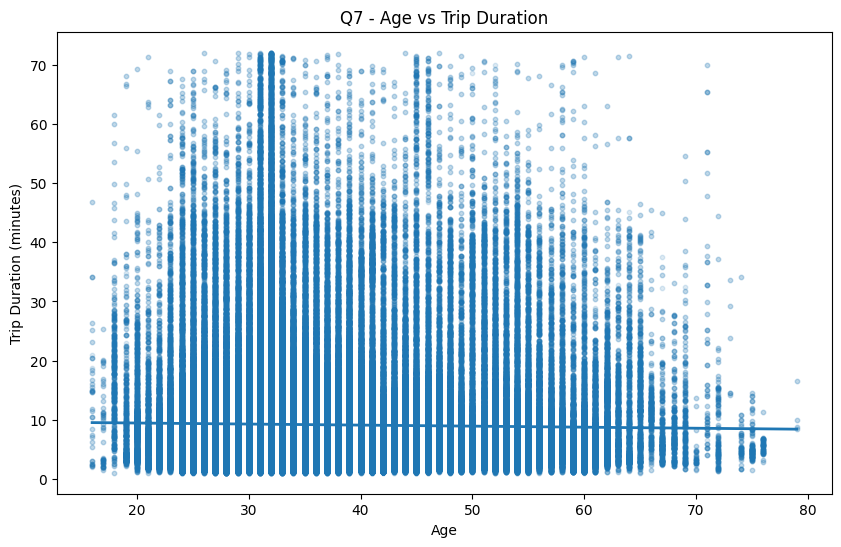

In [8]:
plt.figure(figsize=(10, 6))
plt.scatter(q7["Age"], q7["Trip_Duration_Min"], alpha=0.15, s=10)

# Regression line
m, b = np.polyfit(q7["Age"], q7["Trip_Duration_Min"], 1)
x_line = np.linspace(q7["Age"].min(), q7["Age"].max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, linewidth=2)

plt.title("Q7 - Age vs Trip Duration")
plt.xlabel("Age")
plt.ylabel("Trip Duration (minutes)")
plt.show()

### Mean trip duration by age group

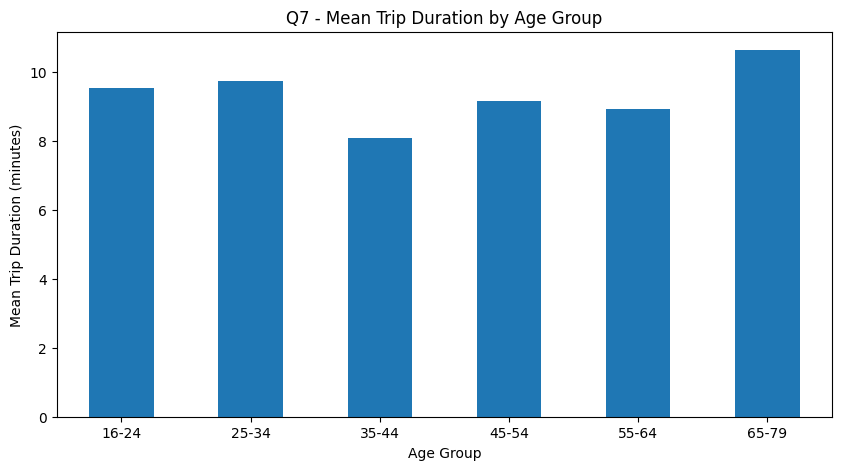

Age_Group
16-24     9.535097
25-34     9.748153
35-44     8.073127
45-54     9.151574
55-64     8.919341
65-79    10.632746
Name: Trip_Duration_Min, dtype: float64


In [9]:
bins = [16, 25, 35, 45, 55, 65, 80]
labels = ["16-24", "25-34", "35-44", "45-54", "55-64", "65-79"]

q7["Age_Group"] = pd.cut(q7["Age"], bins=bins, labels=labels, right=False)

mean_by_age_group = q7.groupby("Age_Group", observed=True)["Trip_Duration_Min"].mean()

plt.figure(figsize=(10, 5))
mean_by_age_group.plot(kind="bar")
plt.title("Q7 - Mean Trip Duration by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Mean Trip Duration (minutes)")
plt.xticks(rotation=0)
plt.show()

print(mean_by_age_group)

### Pearson and Spearman correlations

In [10]:
pearson_r, pearson_p = pearsonr(q7["Age"], q7["Trip_Duration_Min"])
spearman_rho, spearman_p = spearmanr(q7["Age"], q7["Trip_Duration_Min"])

print("Pearson r =", pearson_r)
print("Pearson p-value =", pearson_p)
print("Spearman rho =", spearman_rho)
print("Spearman p-value =", spearman_p)

Pearson r = -0.019329791112523222
Pearson p-value = 4.1169121080215786e-61
Spearman rho = -0.04438345906236206
Spearman p-value = 0.0


In [11]:
x = q7["Age"].to_numpy()
y = q7["Trip_Duration_Min"].to_numpy()

n = len(x)

x_bar = x.mean()
y_bar = y.mean()

ss_x = ((x - x_bar) ** 2).sum()
ss_y = ((y - y_bar) ** 2).sum()
sp_xy = ((x - x_bar) * (y - y_bar)).sum()

sigma_x = np.sqrt(((x - x_bar) ** 2).mean())
sigma_y = np.sqrt(((y - y_bar) ** 2).mean())
cov_xy = ((x - x_bar) * (y - y_bar)).mean()

pearson_manual = sp_xy / np.sqrt(ss_x * ss_y)

print("Step 1: n =", n)
print("Step 2: mean age (x̄) =", x_bar)
print("Step 3: mean trip duration (ȳ) =", y_bar)
print("Step 4: Σ(xi - x̄)^2 =", ss_x)
print("Step 5: Σ(yi - ȳ)^2 =", ss_y)
print("Step 6: Σ[(xi - x̄)(yi - ȳ)] =", sp_xy)
print("Step 7: σx =", sigma_x)
print("Step 8: σy =", sigma_y)
print("Step 9: cov(x,y) =", cov_xy)
print("Step 10: Pearson r =", pearson_manual)

Step 1: n = 727893
Step 2: mean age (x̄) = 36.411608574337166
Step 3: mean trip duration (ȳ) = 9.138314147821177
Step 4: Σ(xi - x̄)^2 = 63635052.18986856
Step 5: Σ(yi - ȳ)^2 = 52934732.19761263
Step 6: Σ[(xi - x̄)(yi - ȳ)] = -1121878.2368862596
Step 7: σx = 9.35006071253491
Step 8: σy = 8.527791797670712
Step 9: cov(x,y) = -1.5412680667162064
Step 10: Pearson r = -0.019329791112523226


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# -------------------------
# Load and prepare data
# -------------------------
df = pd.read_csv("New York Citi Bike Trip Histories 2015 - 2017.csv")

df["Gender"] = pd.to_numeric(df["Gender"], errors="coerce")

q8 = df[["Gender", "Start Station Name"]].dropna()
q8 = q8[q8["Gender"].isin([1, 2])].copy()

q8["GenderLabel"] = q8["Gender"].map({1: "Male", 2: "Female"})

print(q8["GenderLabel"].value_counts())

GenderLabel
Male      525608
Female    150426
Name: count, dtype: int64


In [13]:
male_top = q8[q8["GenderLabel"] == "Male"]["Start Station Name"].value_counts().head(5)
female_top = q8[q8["GenderLabel"] == "Female"]["Start Station Name"].value_counts().head(5)

print("Top 5 Male Start Stations")
print(male_top)
print()

print("Top 5 Female Start Stations")
print(female_top)

Top 5 Male Start Stations
Start Station Name
Grove St PATH     63071
Exchange Place    39787
Sip Ave           38843
Hamilton Park     34047
Newport PATH      28865
Name: count, dtype: int64

Top 5 Female Start Stations
Start Station Name
Grove St PATH     19092
Exchange Place    10417
Hamilton Park     10370
Sip Ave            8317
Van Vorst Park     7916
Name: count, dtype: int64


In [14]:
top_stations = sorted(set(male_top.index).union(set(female_top.index)))

plot_table = pd.crosstab(q8["Start Station Name"], q8["GenderLabel"]).loc[top_stations]

print(plot_table)

GenderLabel         Female   Male
Start Station Name               
Exchange Place       10417  39787
Grove St PATH        19092  63071
Hamilton Park        10370  34047
Newport PATH          7156  28865
Sip Ave               8317  38843
Van Vorst Park        7916  17435


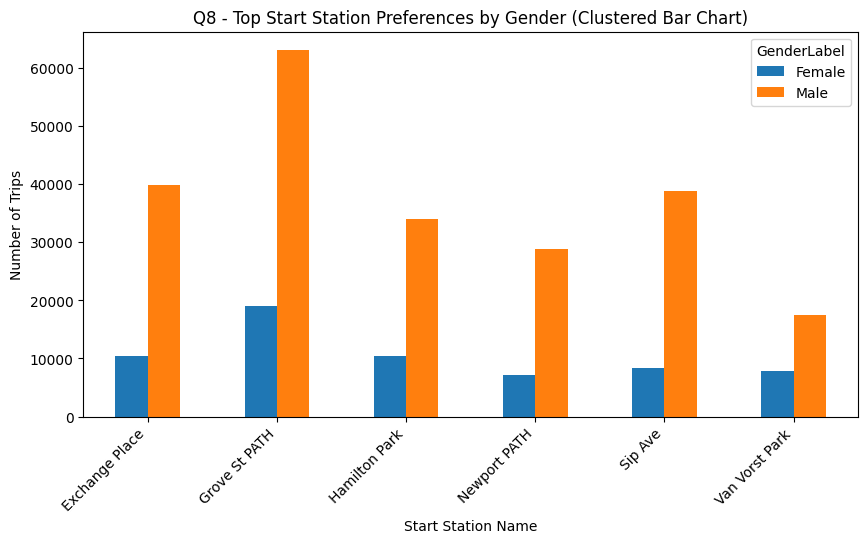

In [15]:
plot_table.plot(kind="bar", stacked=False, figsize=(10, 5))
plt.title("Q8 - Top Start Station Preferences by Gender (Clustered Bar Chart)")
plt.xlabel("Start Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()

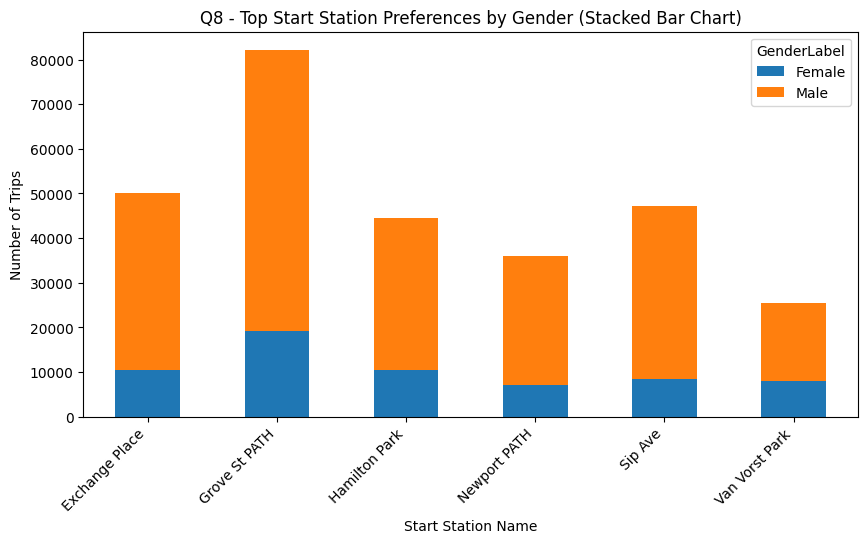

In [16]:
plot_table.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("Q8 - Top Start Station Preferences by Gender (Stacked Bar Chart)")
plt.xlabel("Start Station Name")
plt.ylabel("Number of Trips")
plt.xticks(rotation=45, ha="right")
plt.show()

In [17]:
male_total = (q8["GenderLabel"] == "Male").sum()
female_total = (q8["GenderLabel"] == "Female").sum()

male_pct = (male_top / male_total) * 100
female_pct = (female_top / female_total) * 100

print("Male percentages")
print(male_pct)
print()
print("Female percentages")
print(female_pct)

Male percentages
Start Station Name
Grove St PATH     11.999627
Exchange Place     7.569710
Sip Ave            7.390108
Hamilton Park      6.477641
Newport PATH       5.491735
Name: count, dtype: float64

Female percentages
Start Station Name
Grove St PATH     12.691955
Exchange Place     6.925000
Hamilton Park      6.893755
Sip Ave            5.528964
Van Vorst Park     5.262388
Name: count, dtype: float64


In [18]:
q8["StationGroup"] = np.where(q8["Start Station Name"].isin(top_stations),
                              q8["Start Station Name"],
                              "Other")

ct = pd.crosstab(q8["StationGroup"], q8["GenderLabel"])
ct = ct.loc[top_stations + ["Other"]]

print("Contingency Table")
print(ct)

Contingency Table
GenderLabel     Female    Male
StationGroup                  
Exchange Place   10417   39787
Grove St PATH    19092   63071
Hamilton Park    10370   34047
Newport PATH      7156   28865
Sip Ave           8317   38843
Van Vorst Park    7916   17435
Other            87158  303560


In [19]:
chi2, p, dof, expected = chi2_contingency(ct)

print("Chi-square =", chi2)
print("p-value =", p)
print("Degrees of freedom =", dof)

expected_df = pd.DataFrame(expected, index=ct.index, columns=ct.columns)
print()
print("Expected Frequencies")
print(expected_df)

Chi-square = 2022.4719380768277
p-value = 0.0
Degrees of freedom = 6

Expected Frequencies
GenderLabel           Female           Male
StationGroup                               
Exchange Place  11171.016405   39032.983595
Grove St PATH   18282.292663   63880.707337
Hamilton Park    9883.336699   34533.663301
Newport PATH     8015.121941   28005.878059
Sip Ave         10493.688424   36666.311576
Van Vorst Park   5640.913809   19710.086191
Other           86939.630060  303778.369940


In [20]:
grand_total = ct.values.sum()
row_total = ct.loc["Grove St PATH"].sum()
col_total = ct["Male"].sum()

observed = ct.loc["Grove St PATH", "Male"]
expected_value = (row_total * col_total) / grand_total

contribution = ((observed - expected_value) ** 2) / expected_value

print("Grand total =", grand_total)
print("Row total for Grove St PATH =", row_total)
print("Column total for Male =", col_total)
print("Observed O =", observed)
print("Expected E =", expected_value)
print("Chi-square contribution =", contribution)

Grand total = 676034
Row total for Grove St PATH = 82163
Column total for Male = 525608
Observed O = 63071
Expected E = 63880.707337204934
Chi-square contribution = 10.263286041318777
